### Imports

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### CSV Columns

These are the universal names for columns we have in the CSV file so that if the CSV file has a different name for a column we don't have to change it

In [14]:
# universal names for each column in the csv, added so that if the names are different we just have to change it here
# change the right values to what they are called in the csv file
CSV_COLUMNS = {
    "gene_name": "gene_name",
    "log2_fold_change": "log2FoldChange",
    "pvalue": "pvalue",
    "log_pvalue": "log_pvalue",
    "seq_length": "Sequence_Length",
    "first3": "First_3",
    "last3": "Last_3",
    "gc_pct": "GC_pct",
    "at_pct": "AT_pct",
}

### One Hot Encoding

For our first 3 and last 3 bases data, we want the neural network to take into account the actual sequence of each base, not the simple 3 letter string. We do this using one hot encoding, and so this function returns that data formatted properly.

### Classes

- GeneDataset formats data in a way PyTorch understands.
- GeneMLP is the structure of our neural network.
- TrainedModel stores our trained neural network to use/test for later.

In [15]:
# pytorch dataset to handle data in correct format
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# neural network model to predict numerical data
class GeneMLP(nn.Module):
    # input_dim = # of features in input matrix X
    # hidden1 = number of neurons hidden in the first layer
    #   - produces a number of outputs containing initial patterns
    # hidden2 = number of neurons hidden in the second layer
    #   - takes the outputs from the first layer and compresses it to smaller dimensions
    #   - helps distill the more important features
    # dropout = the % chance of a neuron "turning off" during training. this prevents:
    #   - the network becoming overly dependent on certain features (memorization)
    def __init__(self, input_dim, hidden1=32, hidden2=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    # pass input matrix X through neural network
    def forward(self, x):
        return self.net(x)

class TrainedModel:
    def __init__(self, fold_models, history, output, X_arr, y_arr):
        self.fold_models = fold_models
        self.history = history
        self.output_type = output
        self.X_arr = X_arr
        self.y_arr = y_arr

### Train One Fold

This function takes one piece of the data, builds a fresh neural network from scratch, and iteratively trains its weights to minimize prediction errors. It simultaneously monitors a separate validation set to prevent overfitting, automatically stopping the process the moment the model stops improving and returning the best version of the network.

### Train Model

This function combines everything and returns a TrainedModel object. 

Parameters:
- input_file: the name of the file you want to train data on
- target_key: the name of the key in CSV_COLUMNS for the target data you want to predict
- data_pct: the percentage of data you want to train the model on

### Test Model

This function calculates baseline metrics and compares them to the metrics of our model, generating visualizers in the process.

In [16]:
BASES = ["A", "C", "G", "T"]
def one_hot_sequence(series, prefix, seq_len):
    """One-hot encode a column of fixed-length DNA sequence strings into
    seq_len x 4 binary columns (one column per position x base)."""
    out = pd.DataFrame(index=series.index)
    for pos in range(seq_len):
        for base in BASES:
            col_name = f"{prefix}_pos{pos+1}_{base}"
            out[col_name] = (series.str.upper().str[pos] == base).astype(int)
    return out

In [17]:
class SDRegionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # class indices, not floats

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class RegulationMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.3, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [45]:
def train_one_fold_regulation(X_train, y_train, X_val, y_val, input_dim,
                               epochs=300, patience=20, lr=1e-4, weight_decay=1e-3,
                               batch_size=32, verbose=False):
    train_loader = DataLoader(SDRegionDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SDRegionDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    # Remove "Neither" class if present
    train_mask = y_train != 2
    val_mask = y_val != 2

    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    X_val = X_val[val_mask]
    y_val = y_val[val_mask]

    # Convert labels:
    # 0 = Down
    # 2 = Up  --> 1
    y_train = np.where(y_train == 2, 1, y_train)
    y_val = np.where(y_val == 2, 1, y_val)

    model = RegulationMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # class weights to handle imbalance across down/neither/up
    class_counts = np.bincount(y_train.astype(int), minlength=2)

    class_weights = class_counts.sum() / (
        2 * np.maximum(class_counts, 1)
    )

    weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )

    loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d} train={train_loss:.4f}  val={val_loss:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break

    if best_state is None:
        best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, history

In [19]:
def train_model_regulation(input_file, data_pct=None, epochs=3000):
    SEQ_LEN = 34
    seq_col = "Extracted_SD_Region"
    target_col = "regulation"

    print(f"Training neural network on file {input_file} to predict regulation "
          f"(-1=down, 0=neither, 1=up) from {seq_col}")

    df_full = pd.read_csv(input_file)
    print(f"\nExtracted data from {input_file}: {len(df_full)} rows")

    # sanity check on sequence length
    bad_len = df_full[seq_col].str.len().ne(SEQ_LEN).sum()
    if bad_len > 0:
        print(f"Warning: {bad_len} rows do not have {SEQ_LEN}-character sequences")

    if data_pct is None:
        data_pct = 0.5

    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")
    df = df[df[target_col] != 0].reset_index(drop=True)

    X = one_hot_sequence(df[seq_col], "sd", SEQ_LEN)
    print(f"Feature matrix built from {seq_col} ({SEQ_LEN} positions x 4 bases)")

    # map regulation values {-1, 0, 1} -> class indices {0, 1, 2}
    label_map = {
        -1: 0,   # Down
        1: 1    # Up
    }
    y = df[target_col].map(label_map).values.astype(np.int64)

    print("Feature matrix shape:", X.shape)
    counts = np.bincount(y, minlength=2)
    print(f"Target class distribution -> Down: {counts[0]}  Up: {counts[1]}")
    
    X_arr = X.values.astype(np.float32)
    y_arr = y

    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        model, history = train_one_fold_regulation(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True, epochs=epochs
        )

        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        val_pred_labels = val_logits.argmax(axis=1)

        acc = accuracy_score(y_val, val_pred_labels)
        f1 = f1_score(y_val, val_pred_labels, average="macro", zero_division=0)
        precision = precision_score(y_val, val_pred_labels, average="macro", zero_division=0)

        print(f"  Fold {fold_idx+1}  Accuracy={acc:.4f}  Macro F1={f1:.4f}  Macro Precision={precision:.4f}")
        fold_results.append({"fold": fold_idx + 1, "accuracy": acc, "f1": f1, "precision": precision})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean Accuracy:        {results_df['accuracy'].mean():.4f}  +/- {results_df['accuracy'].std():.4f}")
    print(f"Mean Macro F1:        {results_df['f1'].mean():.4f}  +/- {results_df['f1'].std():.4f}")
    print(f"Mean Macro Precision: {results_df['precision'].mean():.4f}  +/- {results_df['precision'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Training curve — last fold (Regulation Classifier)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return TrainedModel(fold_models, history, target_col, X_arr, y_arr)

In [20]:
def test_model_regulation(trained_model):
    all_true = []
    all_pred = []

    fold_models = trained_model.fold_models
    X_arr = trained_model.X_arr
    y_arr = trained_model.y_arr

    for model, scaler, val_idx in fold_models:
        X_val_raw = X_arr[val_idx]
        X_val_scaled = scaler.transform(X_val_raw)

        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
            logits = model(X_tensor).cpu().numpy()

        preds = logits.argmax(axis=1)

        all_true.extend(y_arr[val_idx])
        all_pred.extend(preds)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    class_names = ["Down (-1)", "Up (1)"]

    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    overall_precision = precision_score(all_true, all_pred, average="macro", zero_division=0)

    majority_class = np.bincount(y_arr, minlength=2).argmax()
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)

    print("=== Evaluation Dashboard: Regulation (Down / Up) ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | Macro F1: {overall_f1:.4f} | Macro Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting '{class_names[majority_class]}')")

    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")

    print("=" * 60 + "\n")

    per_class_precision = precision_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_recall = recall_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_f1 = f1_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(all_true, all_pred, labels=[0, 1])

    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, str(cm[i, j]),
                         va="center", ha="center",
                         size="large", weight="bold")

    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(class_names)
    axes[0].set_yticklabels(class_names)
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")

    x = np.arange(2)
    width = 0.25

    axes[1].bar(x - width, per_class_precision, width, label="Precision", color="crimson")
    axes[1].bar(x, per_class_recall, width, label="Recall", color="teal")
    axes[1].bar(x + width, per_class_f1, width, label="F1", color="dimgray")

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Per-Class Metrics")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "accuracy": overall_acc,
        "f1_macro": overall_f1,
        "precision_macro": overall_precision,
    }

In [36]:
def test_independent_file_regulation(trained_model_obj, test_file):
    """
    Evaluates the trained ensemble on a completely new test file containing
    Extracted_SD_Region and regulation columns.

    Assumes binary classification:
        -1 -> Down (0)
         1 -> Up   (1)

    Rows with regulation == 0 are ignored.
    """
    seq_col = "Extracted_SD_Region"
    target_col = "regulation"
    SEQ_LEN = 34

    df_test = pd.read_csv(test_file)

    # Keep only Down and Up examples
    df_test = df_test[df_test[target_col] != 0].reset_index(drop=True)

    if len(df_test) == 0:
        print("Error: No valid data in test file.")
        return None

    X_test_raw = one_hot_sequence(
        df_test[seq_col],
        "sd",
        SEQ_LEN
    ).values.astype(np.float32)

    # Binary labels
    label_map = {-1: 0, 1: 1}
    all_true = df_test[target_col].map(label_map).values.astype(np.int64)

    all_fold_probs = []

    first_model = trained_model_obj.fold_models[0][0]
    device = next(first_model.parameters()).device

    for model, scaler, _ in trained_model_obj.fold_models:
        model.eval()

        X_test_scaled = scaler.transform(X_test_raw)
        X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

        with torch.no_grad():
            logits = model(X_tensor).cpu().numpy()

            # Softmax
            exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
            probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)

            all_fold_probs.append(probs)

    # Average predictions from all folds
    mean_probs = np.mean(all_fold_probs, axis=0)
    all_pred = mean_probs.argmax(axis=1)

    class_names = ["Down (-1)", "Up (1)"]

    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    overall_precision = precision_score(all_true, all_pred, average="macro", zero_division=0)

    majority_class = np.bincount(all_true, minlength=2).argmax()
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)

    print("=== Independent Test Dashboard: Regulation (Down / Up) ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | Macro F1: {overall_f1:.4f} | Macro Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting '{class_names[majority_class]}')")

    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")

    print("=" * 60 + "\n")

    # Per-class metrics
    per_class_precision = precision_score(
        all_true, all_pred,
        average=None,
        labels=[0, 1],
        zero_division=0
    )

    per_class_recall = recall_score(
        all_true, all_pred,
        average=None,
        labels=[0, 1],
        zero_division=0
    )

    per_class_f1 = f1_score(
        all_true, all_pred,
        average=None,
        labels=[0, 1],
        zero_division=0
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion matrix
    cm = confusion_matrix(all_true, all_pred, labels=[0, 1])

    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(
                j, i,
                str(cm[i, j]),
                va="center",
                ha="center",
                size="large",
                weight="bold"
            )

    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(class_names)
    axes[0].set_yticklabels(class_names)
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")

    # Per-class bar chart
    x = np.arange(2)
    width = 0.25

    axes[1].bar(x - width, per_class_precision, width, label="Precision")
    axes[1].bar(x, per_class_recall, width, label="Recall")
    axes[1].bar(x + width, per_class_f1, width, label="F1")

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Per-Class Metrics")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "accuracy": overall_acc,
        "f1_macro": overall_f1,
        "precision_macro": overall_precision,
    }

Training neural network on file PA_shine_data.csv to predict regulation (-1=down, 0=neither, 1=up) from Extracted_SD_Region

Extracted data from PA_shine_data.csv: 412 rows
Separated a random sample of 206/412 rows of data for training
Feature matrix built from Extracted_SD_Region (34 positions x 4 bases)
Feature matrix shape: (25, 136)
Target class distribution -> Down: 19  Up: 6

Training model...
--- Fold 1/5 ---
  epoch   0 train=0.7122  val=0.7127
  epoch  20 train=0.6416  val=0.7174
  early stopping at epoch 20
  Fold 1  Accuracy=0.8000  Macro F1=0.7619  Macro Precision=0.8750
--- Fold 2/5 ---
  epoch   0 train=0.6997  val=0.6700
  epoch  20 train=0.6672  val=0.6725
  early stopping at epoch 20
  Fold 2  Accuracy=0.4000  Macro F1=0.2857  Macro Precision=0.2000
--- Fold 3/5 ---
  epoch   0 train=0.6985  val=0.6814
  epoch  20 train=0.6327  val=0.6787
  epoch  40 train=0.6635  val=0.6762
  epoch  60 train=0.6225  val=0.6743
  epoch  80 train=0.5994  val=0.6724


C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

  epoch 100 train=0.5630  val=0.6709
  epoch 120 train=0.4728  val=0.6676
  epoch 140 train=0.4972  val=0.6621
  epoch 160 train=0.4072  val=0.6562
  epoch 180 train=0.3971  val=0.6508
  epoch 200 train=0.3208  val=0.6436
  epoch 220 train=0.3261  val=0.6372
  epoch 240 train=0.3407  val=0.6291
  epoch 260 train=0.3014  val=0.6199
  epoch 280 train=0.2082  val=0.6086
  epoch 300 train=0.1991  val=0.5980
  epoch 320 train=0.1597  val=0.5870
  epoch 340 train=0.1575  val=0.5756
  epoch 360 train=0.1151  val=0.5653
  epoch 380 train=0.1387  val=0.5552
  epoch 400 train=0.1552  val=0.5446
  epoch 420 train=0.1008  val=0.5340
  epoch 440 train=0.1003  val=0.5246
  epoch 460 train=0.0732  val=0.5152
  epoch 480 train=0.0653  val=0.5057
  epoch 500 train=0.0709  val=0.4981
  epoch 520 train=0.0356  val=0.4909
  epoch 540 train=0.0465  val=0.4834
  epoch 560 train=0.0547  val=0.4777
  epoch 580 train=0.0464  val=0.4726
  epoch 600 train=0.0451  val=0.4675
  epoch 620 train=0.0394  val=0.4634
 

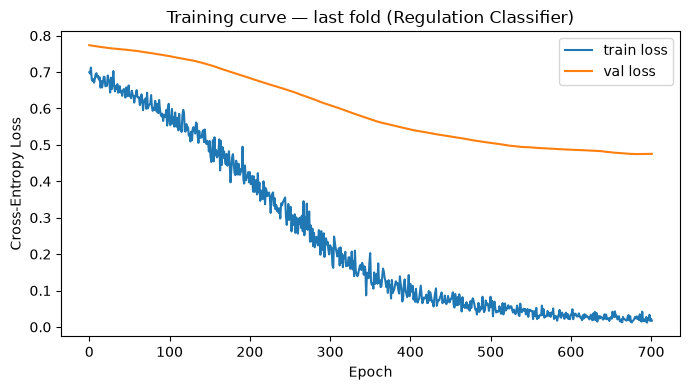

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.8136 | Macro F1: 0.7030 | Macro Precision: 0.6810
Baseline Metrics -> Accuracy: 0.8475 (always predicting 'Down (-1)')
⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.



C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

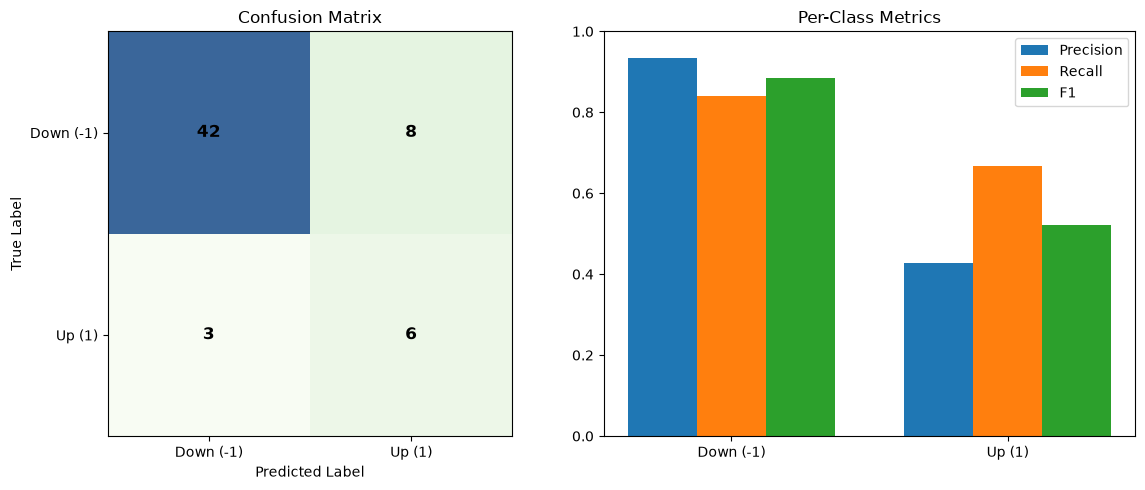

C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.5220 | Macro F1: 0.5215 | Macro Precision: 0.5308
Baseline Metrics -> Accuracy: 0.5847 (always predicting 'Down (-1)')
⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.



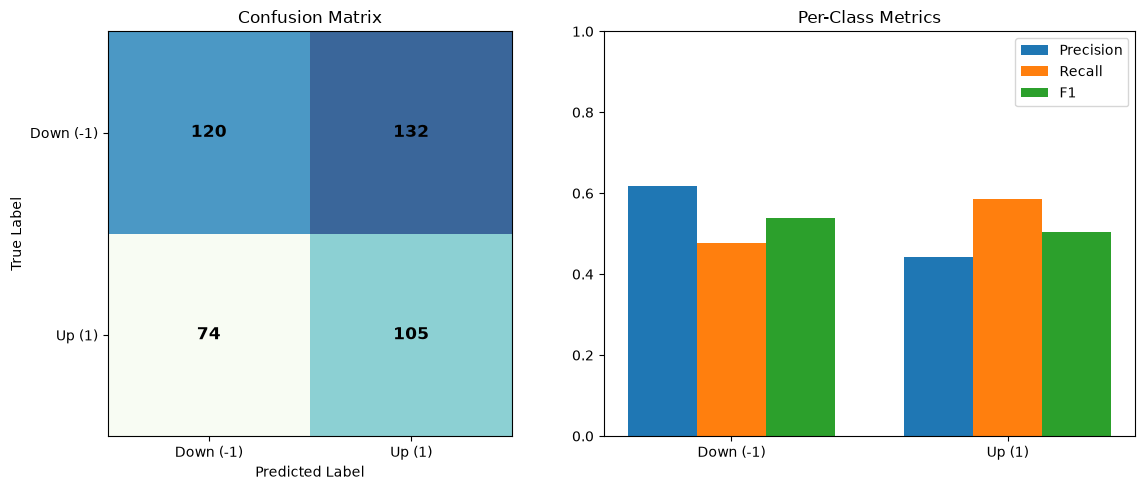

{'accuracy': 0.5220417633410673,
 'f1_macro': 0.5214621421179717,
 'precision_macro': 0.530797337857236}

In [ ]:
mod = train_model_regulation("PA_shine_data.csv", data_pct=.5, epochs=9000)
test_independent_file_regulation(mod, "PA_shine_data.csv")
test_independent_file_regulation(mod, "pa_staph_shine.csv")
test_independent_file_regulation(mod, "SA_shine_data.csv")
# or, on a held-out file:
# test_independent_file_regulation(mod, "some_other_file.csv")

Training neural network on file SA_shine_data.csv to predict regulation (-1=down, 0=neither, 1=up) from Extracted_SD_Region

Extracted data from SA_shine_data.csv: 700 rows
Separated a random sample of 350/700 rows of data for training
Feature matrix built from Extracted_SD_Region (34 positions x 4 bases)
Feature matrix shape: (184, 136)
Target class distribution -> Down: 88  Up: 96

Training model...
--- Fold 1/5 ---
  epoch   0 train=0.7088  val=0.6813


C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

  epoch  20 train=0.6848  val=0.6919
  early stopping at epoch 20
  Fold 1  Accuracy=0.5405  Macro F1=0.3509  Macro Precision=0.2703
--- Fold 2/5 ---
  epoch   0 train=0.7035  val=0.7084
  epoch  20 train=0.6802  val=0.7000
  epoch  40 train=0.6539  val=0.6951
  epoch  60 train=0.6213  val=0.6905
  epoch  80 train=0.5587  val=0.6809
  epoch 100 train=0.4790  val=0.6715
  epoch 120 train=0.3802  val=0.6643
  epoch 140 train=0.2787  val=0.6632
  early stopping at epoch 149
  Fold 2  Accuracy=0.5946  Macro F1=0.5934  Macro Precision=0.5965
--- Fold 3/5 ---
  epoch   0 train=0.6971  val=0.6836
  epoch  20 train=0.6750  val=0.6926
  early stopping at epoch 20
  Fold 3  Accuracy=0.4595  Macro F1=0.4394  Macro Precision=0.4483
--- Fold 4/5 ---
  epoch   0 train=0.6976  val=0.6927
  epoch  20 train=0.6727  val=0.6924
  early stopping at epoch 27
  Fold 4  Accuracy=0.4865  Macro F1=0.4804  Macro Precision=0.4891
--- Fold 5/5 ---
  epoch   0 train=0.6972  val=0.7088
  epoch  20 train=0.6811  val

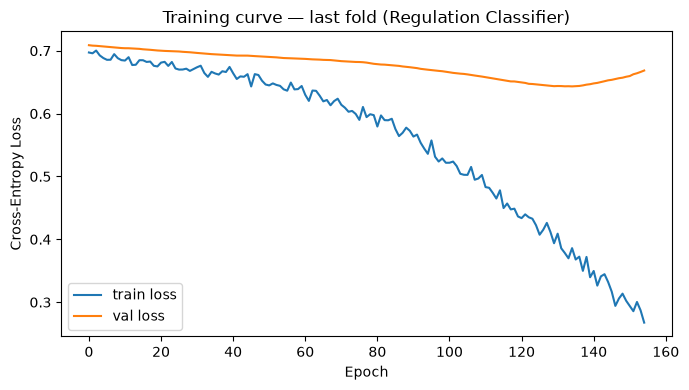

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.7285 | Macro F1: 0.7273 | Macro Precision: 0.7269
Baseline Metrics -> Accuracy: 0.5430 (always predicting 'Down (-1)')
✅ Neural Network performing better than baseline accuracy



C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

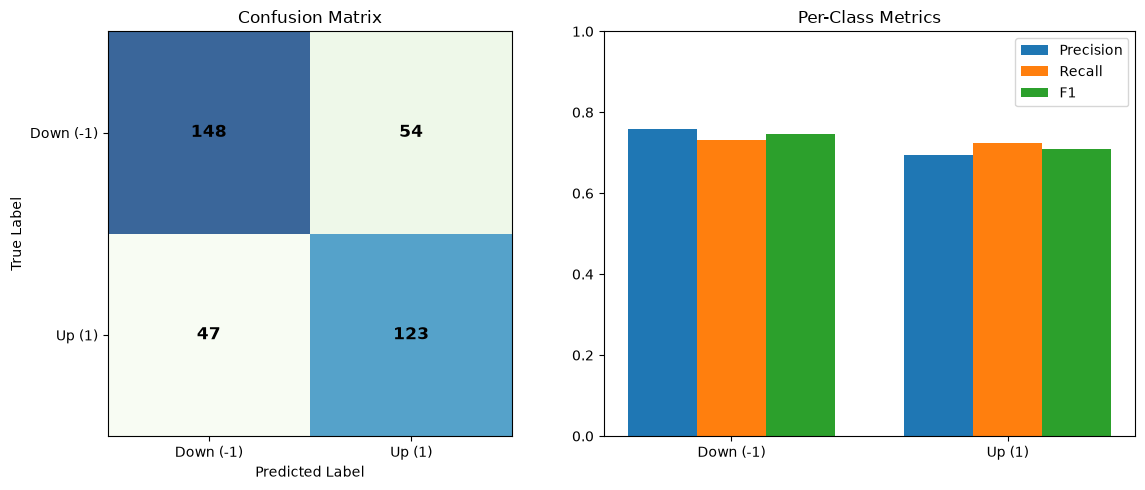

C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)


=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.6891 | Macro F1: 0.6854 | Macro Precision: 0.6854
Baseline Metrics -> Accuracy: 0.5847 (always predicting 'Down (-1)')
✅ Neural Network performing better than baseline accuracy



C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

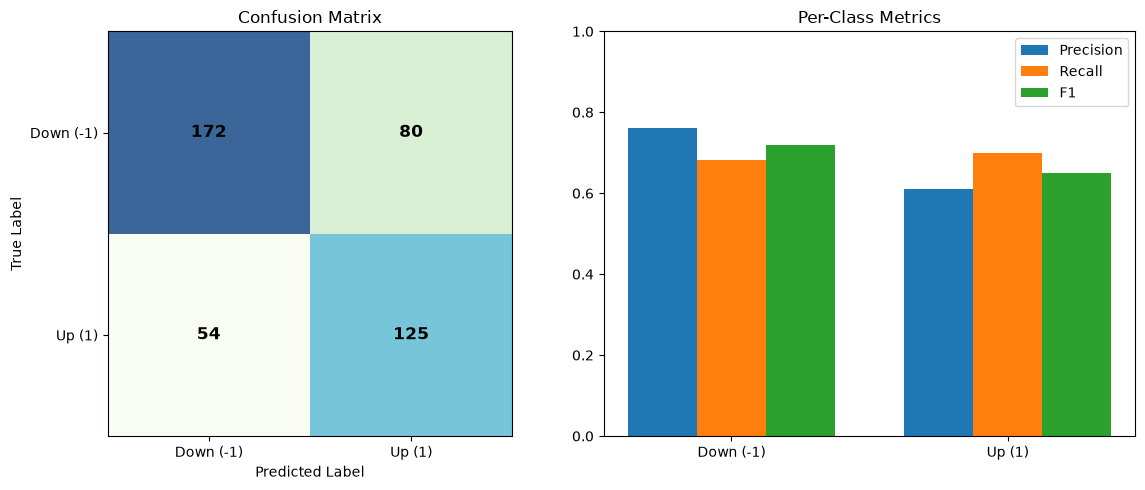

C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.4407 | Macro F1: 0.3504 | Macro Precision: 0.4228
Baseline Metrics -> Accuracy: 0.8475 (always predicting 'Down (-1)')
⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.



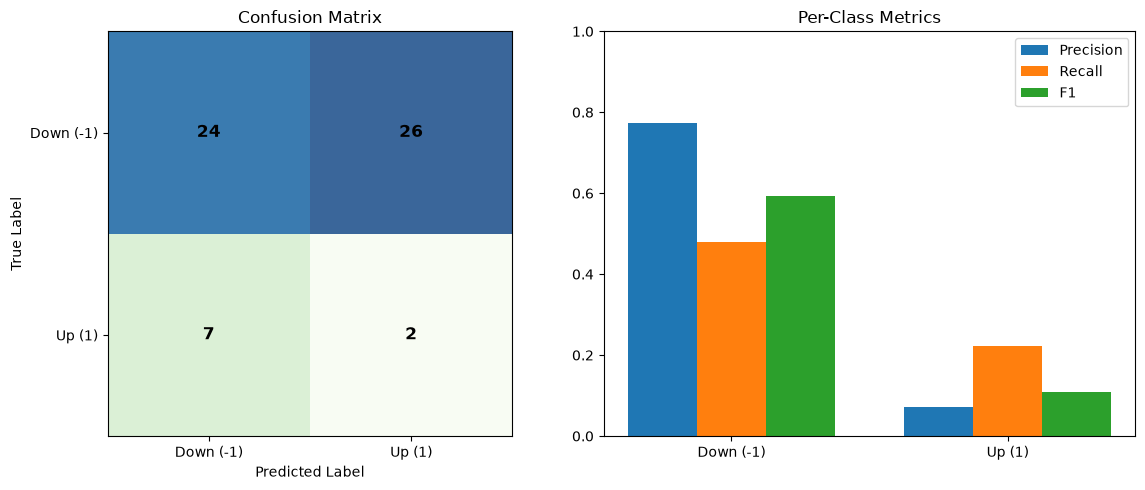

{'accuracy': 0.4406779661016949,
 'f1_macro': 0.35035035035035034,
 'precision_macro': 0.4228110599078341}

In [54]:
mod = train_model_regulation("SA_shine_data.csv", data_pct=.5, epochs=9000)
test_independent_file_regulation(mod, "SA_shine_data.csv")
test_independent_file_regulation(mod, "pa_staph_shine.csv")
test_independent_file_regulation(mod, "PA_shine_data.csv")
# or, on a held-out file:
# test_independent_file_regulation(mod, "some_other_file.csv")

Training neural network on file pa_staph_shine.csv to predict regulation (-1=down, 0=neither, 1=up) from Extracted_SD_Region

Extracted data from pa_staph_shine.csv: 1112 rows
Separated a random sample of 556/1112 rows of data for training
Feature matrix built from Extracted_SD_Region (34 positions x 4 bases)
Feature matrix shape: (218, 136)
Target class distribution -> Down: 118  Up: 100

Training model...
--- Fold 1/5 ---
  epoch   0 train=0.7233  val=0.7156
  epoch  20 train=0.6724  val=0.7045


C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

  epoch  40 train=0.6412  val=0.7015
  epoch  60 train=0.6009  val=0.7021
  early stopping at epoch 66
  Fold 1  Accuracy=0.4318  Macro F1=0.3775  Macro Precision=0.3853
--- Fold 2/5 ---
  epoch   0 train=0.7024  val=0.6716
  epoch  20 train=0.6786  val=0.6780
  early stopping at epoch 20
  Fold 2  Accuracy=0.5909  Macro F1=0.3714  Macro Precision=0.2955
--- Fold 3/5 ---
  epoch   0 train=0.6970  val=0.6930
  epoch  20 train=0.6754  val=0.6921
  epoch  40 train=0.6534  val=0.6902
  epoch  60 train=0.6188  val=0.6891
  epoch  80 train=0.5593  val=0.6895
  early stopping at epoch 94
  Fold 3  Accuracy=0.4773  Macro F1=0.4748  Macro Precision=0.4869
--- Fold 4/5 ---
  epoch   0 train=0.6869  val=0.7124
  epoch  20 train=0.6752  val=0.7144
  early stopping at epoch 28
  Fold 4  Accuracy=0.3953  Macro F1=0.3950  Macro Precision=0.4167
--- Fold 5/5 ---
  epoch   0 train=0.6967  val=0.7181
  epoch  20 train=0.6735  val=0.7061
  epoch  40 train=0.6645  val=0.6983
  epoch  60 train=0.6128  val=

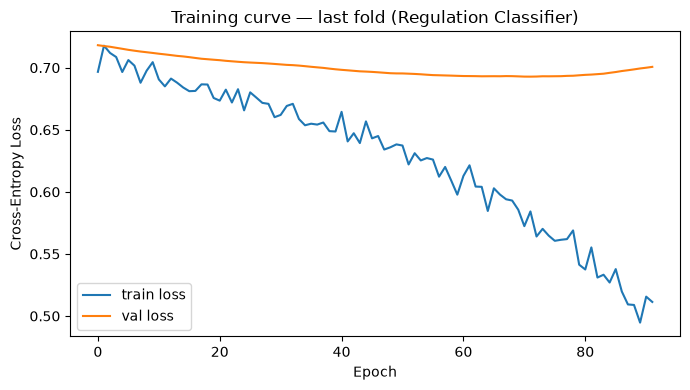

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.7216 | Macro F1: 0.7026 | Macro Precision: 0.7177
Baseline Metrics -> Accuracy: 0.5847 (always predicting 'Down (-1)')
✅ Neural Network performing better than baseline accuracy



C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

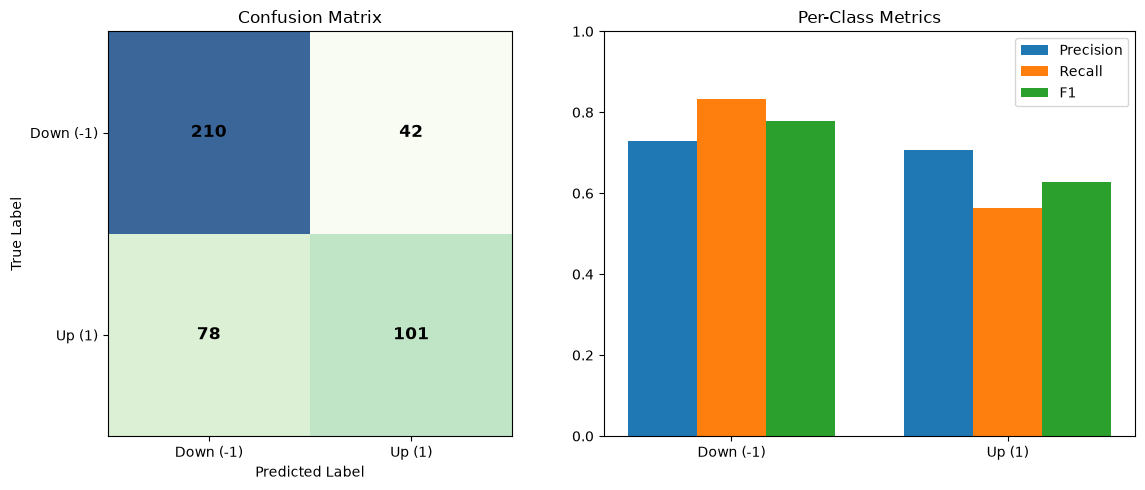

C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.8644 | Macro F1: 0.7108 | Macro Precision: 0.7376
Baseline Metrics -> Accuracy: 0.8475 (always predicting 'Down (-1)')
✅ Neural Network performing better than baseline accuracy



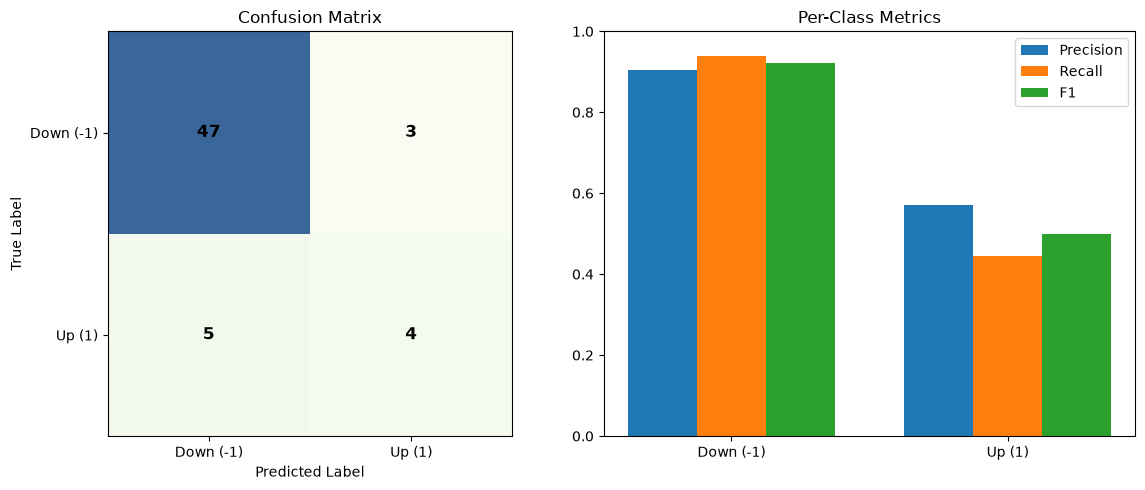

C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_1540\2171591354.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

=== Independent Test Dashboard: Regulation (Down / Up) ===
Model Metrics    -> Accuracy: 0.6989 | Macro F1: 0.6891 | Macro Precision: 0.7020
Baseline Metrics -> Accuracy: 0.5430 (always predicting 'Down (-1)')
✅ Neural Network performing better than baseline accuracy



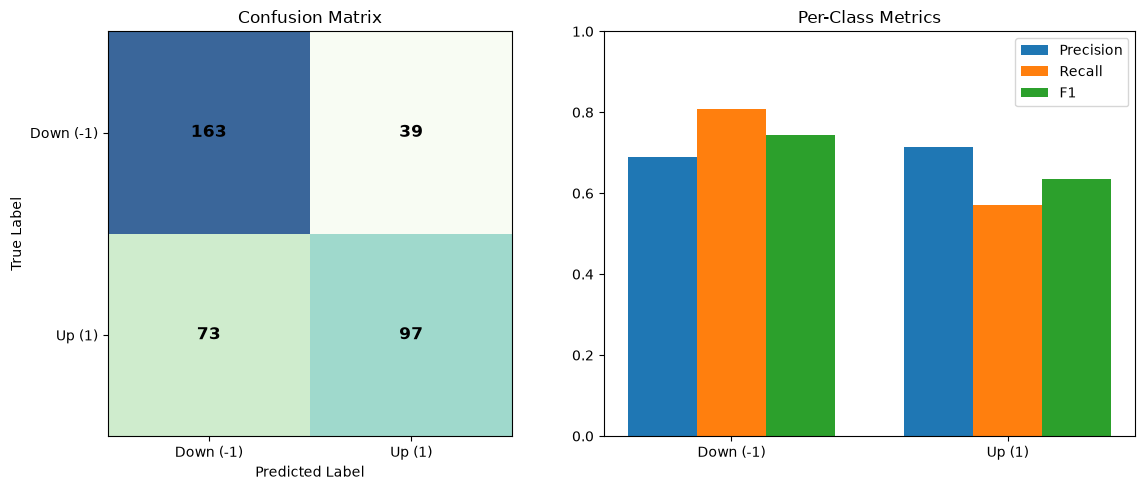

{'accuracy': 0.6989247311827957,
 'f1_macro': 0.6891395827737488,
 'precision_macro': 0.701956630109671}

In [52]:
mod = train_model_regulation("pa_staph_shine.csv", data_pct=.5, epochs=9000)
test_independent_file_regulation(mod, "pa_staph_shine.csv")
test_independent_file_regulation(mod, "PA_shine_data.csv")
test_independent_file_regulation(mod, "SA_shine_data.csv")